# Ілларіонов Микита Іванович
<span style="color:lightblue">Група:ІПЗ 23007Б</span>
**Варіант 5**

Виведення інформації про ОС, шлях до папки проєкту та назву віртуального оточення:

In [1]:
import os
import platform

print(platform.system(), platform.release())
print(os.getcwd())
print(os.environ.get('VIRTUAL_ENV', 'Віртуальне оточення не визначено'))

Linux 6.6.87.2-microsoft-standard-WSL2
/home/jovyan/work
Віртуальне оточення не визначено


1. Створити програму для генерації довільного масиву із 32 цілих чисел, які не перевищують по модулю 255, з наступними властивостями:
1.1. При кожному запуску програми масив повинен бути різним.
1.2. Масив повинен містити від 3 до 4 максимальних (однакових) елементів (розташованих в довільних місцях).
1.3. Масив повинен містити 60 відсотків від'ємних елементів (розташованих в довільних місцях). Щонайменше 6 останніх елементів повинні бути від'ємними.

In [2]:
import random

n = 32
num_neg = int(n * 0.6)
num_max = random.randint(3, 4)
M = random.randint(1, 255)

end_negs = [random.randint(-255, -1) for _ in range(6)]
other_negs = [random.randint(-255, -1) for _ in range(num_neg - 6)]
maxes = [M for _ in range(num_max)]

num_others = n - num_neg - num_max
others = [random.randint(0, M - 1) for _ in range(num_others)]

first_part = other_negs + maxes + others
random.shuffle(first_part)

arr = first_part + end_negs
print("Згенерований масив:")
print(arr)

Згенерований масив:
[95, 83, -199, -27, 34, 7, 72, -61, 2, 95, 62, -185, -179, -205, 30, -173, 28, -139, 95, -154, -236, -133, -86, 86, 9, -219, -102, -221, -205, -146, -205, -92]


2. Зберегти згенерований масив в файл.

In [3]:
with open("array_var5.txt", "w") as f:
    f.write(" ".join(map(str, arr)))
    
print("Масив успішно збережено у файл 'array_var5.txt'")

Масив успішно збережено у файл 'array_var5.txt'


3. Створити програму, яка зчитує із файлу згенерований масив попередньою програмою і виводить його на екран.

In [4]:
with open("array_var5.txt", "r") as f:
    read_arr = list(map(int, f.read().split()))

print("Зчитаний масив:")
print(read_arr)

Зчитаний масив:
[95, 83, -199, -27, 34, 7, 72, -61, 2, 95, 62, -185, -179, -205, 30, -173, 28, -139, 95, -154, -236, -133, -86, 86, 9, -219, -102, -221, -205, -146, -205, -92]


4. Візуалізувати масив за допомогою стовпчастої горизонтальної діаграми. Виділити кольором вершини, які відповідають максимальним елементам, а також вказати ці значення на діаграмі.
Виділити іншим кольором вершини, які відповідають додатнім елементам. (Точки повинні бути не менше 5 пікселів в діаметрі)

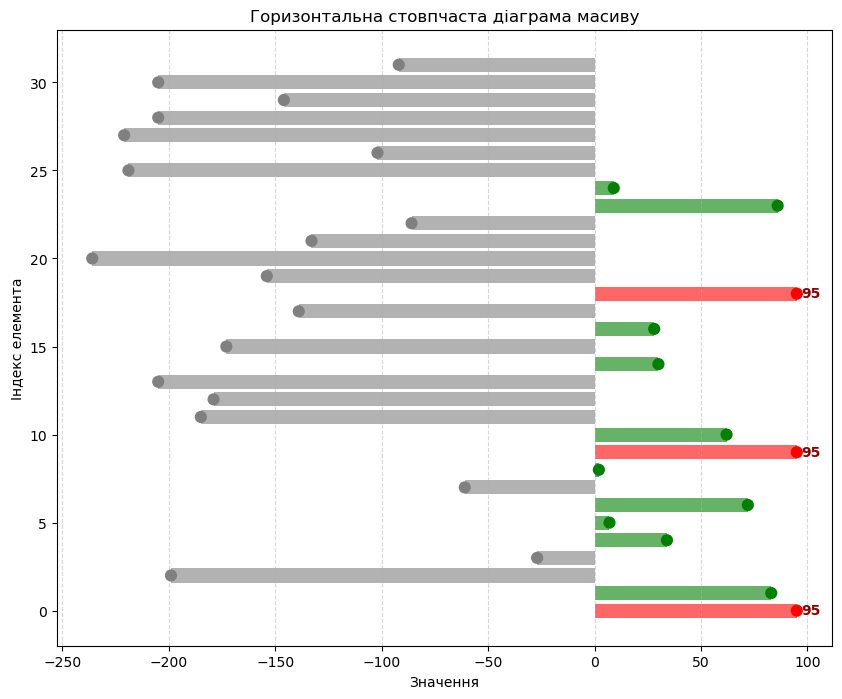

In [5]:
import matplotlib.pyplot as plt

max_val = max(read_arr)

colors = []
for val in read_arr:
    if val == max_val:
        colors.append('red')
    elif val > 0:
        colors.append('green')
    else:
        colors.append('gray')

y_pos = range(len(read_arr))

plt.figure(figsize=(10, 8))

plt.barh(y_pos, read_arr, color=colors, alpha=0.6)

plt.scatter(read_arr, y_pos, color=colors, s=60, zorder=5)

for i, val in enumerate(read_arr):
    if val == max_val:
        plt.text(val + (max_val * 0.02), i, str(val), va='center', fontweight='bold', color='darkred')

plt.title("Горизонтальна стовпчаста діаграма масиву")
plt.xlabel("Значення")
plt.ylabel("Індекс елемента")
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.show()

5. Порахувати кількість та суму елементів масиву, розташованих між другим і третім максимальними.

In [6]:
max_val = max(read_arr)
max_indices = [i for i, val in enumerate(read_arr) if val == max_val]

idx2 = max_indices[1]
idx3 = max_indices[2]

sub_arr = read_arr[idx2 + 1 : idx3]

count_between = len(sub_arr)
sum_between = sum(sub_arr)

print(f"Індекси 2-го та 3-го максимальних елементів: {idx2} та {idx3}")
print(f"Елементи між ними: {sub_arr}")
print(f"Кількість: {count_between}")
print(f"Сума: {sum_between}")

Індекси 2-го та 3-го максимальних елементів: 9 та 18
Елементи між ними: [62, -185, -179, -205, 30, -173, 28, -139]
Кількість: 8
Сума: -761


6. Порахувати суму елементів масиву, розташованих до останнього додатного елементу.

In [7]:
last_pos_idx = -1
for i in range(len(read_arr) - 1, -1, -1):
    if read_arr[i] > 0:
        last_pos_idx = i
        break

if last_pos_idx != -1:
    elements_before = read_arr[:last_pos_idx]
    sum_before = sum(elements_before)
    
    print(f"Останній додатний елемент знаходиться на індексі {last_pos_idx} (значення {read_arr[last_pos_idx]})")
    print(f"Сума елементів до нього: {sum_before}")
else:
    print("В масиві немає додатних елементів.")

Останній додатний елемент знаходиться на індексі 24 (значення 9)
Сума елементів до нього: -1088


7. Стиснути масив, видаливши елементи, які знаходяться в інтервалі [a,b]. a, b – задає користувач. Елементи, що звільнилися в кінці масиву, заповнити нулями. Вивести отриманий масив та його графічну діаграму на екран. Задані користувачем числа відобразити лініями.

Введіть значення a:  -100
Введіть значення b:  100


Інтервал [a, b], заданий користувачем: [-100, 100]
Масив після стиснення (з нулями в кінці):
[-199, -185, -179, -205, -173, -139, -154, -236, -133, -219, -102, -221, -205, -146, -205, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


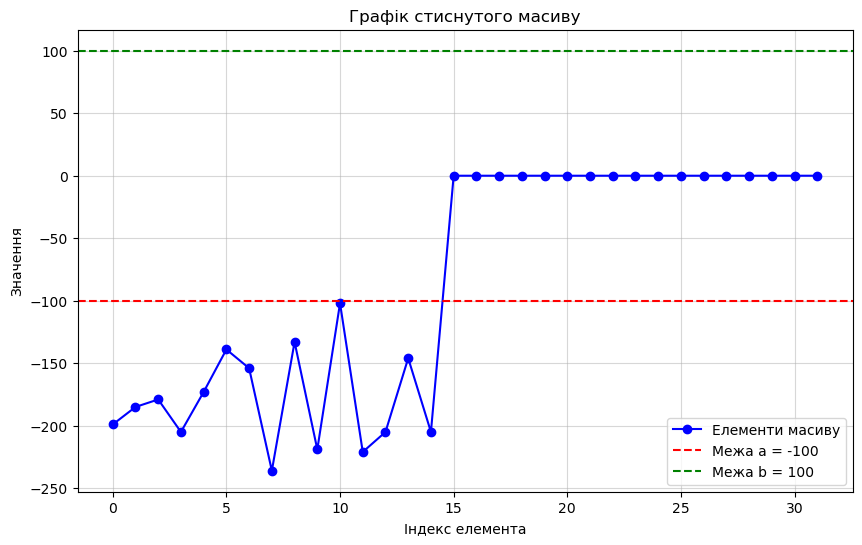

In [8]:
import matplotlib.pyplot as plt

a = int(input("Введіть значення a: "))
b = int(input("Введіть значення b: "))

if a > b:
    a, b = b, a

print(f"Інтервал [a, b], заданий користувачем: [{a}, {b}]")

compressed_arr = []
deleted_count = 0

for val in read_arr:
    if a <= val <= b:
        deleted_count += 1
    else:
        compressed_arr.append(val)


compressed_arr.extend([0] * deleted_count)

print("Масив після стиснення (з нулями в кінці):")
print(compressed_arr)

plt.figure(figsize=(10, 6))

plt.plot(compressed_arr, marker='o', linestyle='-', color='blue', label='Елементи масиву')

plt.axhline(y=a, color='red', linestyle='--', label=f'Межа a = {a}')
plt.axhline(y=b, color='green', linestyle='--', label=f'Межа b = {b}')

plt.title("Графік стиснутого масиву")
plt.xlabel("Індекс елемента")
plt.ylabel("Значення")
plt.legend()
plt.grid(True, alpha=0.5)

plt.show()